# Data Plotting

The dataset `PV_Data_2022.csv` provides hourly measurements of a photovoltaic (PV) system and associated weather data. We'll explore how external conditions like temperature and cloud cover impact the system's energy generation throughout July 2022.

In this example the task is to analyse and visualise the time series data with the help of `pandas` and `matplotlib`.

The tasks are:
1. Load the data and conduct exploratory data screening 
2. Plot the data
3. PV generation statistics
4. Correlation Analysis

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load and explore the data
Hint: `read_csv()`, `.describe()`, `.info()`

Remember how to handle timeseries data (`.to_datetime()`)

In [2]:
df = pd.read_csv("PV_Data_2022.csv")
df["time"] = pd.to_datetime(df["time"])
df

,time,PV Meter,Temperature,Cloud Cover Total,Wind Speed
0,2022-07-01 00:00:00,248870.20,24.821371,0.0,3.396233
1,2022-07-01 01:00:00,248870.20,24.521370,0.0,5.116561
2,2022-07-01 02:00:00,248870.20,23.651371,0.0,3.319036
3,2022-07-01 03:00:00,248870.20,23.111370,0.0,4.198285
4,2022-07-01 04:00:00,248871.52,23.031370,0.0,8.049845
...,...,...,...,...,...
739,2022-07-31 19:00:00,267031.76,25.091370,0.0,16.992609
740,2022-07-31 20:00:00,267031.76,23.791370,0.0,13.532360
741,2022-07-31 21:00:00,267031.76,22.351370,0.0,11.923557
742,2022-07-31 22:00:00,267031.76,21.321371,0.0,8.435069


In [3]:
df.describe()

,time,PV Meter,Temperature,Cloud Cover Total,Wind Speed
count,744,744.000000,744.000000,744.000000,744.000000
mean,2022-07-16 11:29:59.999999744,257547.530699,23.209341,25.130242,9.402260
min,2022-07-01 00:00:00,248870.200000,11.581369,0.000000,0.000000
25%,2022-07-08 17:45:00,252539.210000,20.066371,0.000000,5.081586
50%,2022-07-16 11:30:00,256812.500000,23.086371,0.000000,6.989936
75%,2022-07-24 05:15:00,262612.440000,26.593870,30.250001,11.597084
max,2022-07-31 23:00:00,267031.760000,33.221370,100.000000,35.031162
std,NaN,5553.541338,4.576762,40.310374,6.901375


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   time               744 non-null    datetime64[ns]
 1   PV Meter           744 non-null    float64       
 2   Temperature        744 non-null    float64       
 3   Cloud Cover Total  744 non-null    float64       
 4   Wind Speed         744 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 29.2 KB


## 2. Plot the data
Plot all four data variables over the time. Use an appropiate way to visualse the data (e.g. on figure with different scaled y axis or separate subplots).

<Axes: xlabel='time'>

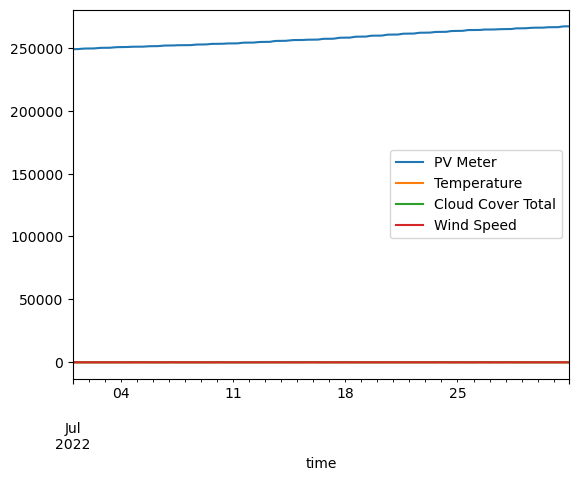

In [5]:
df.plot(x="time")

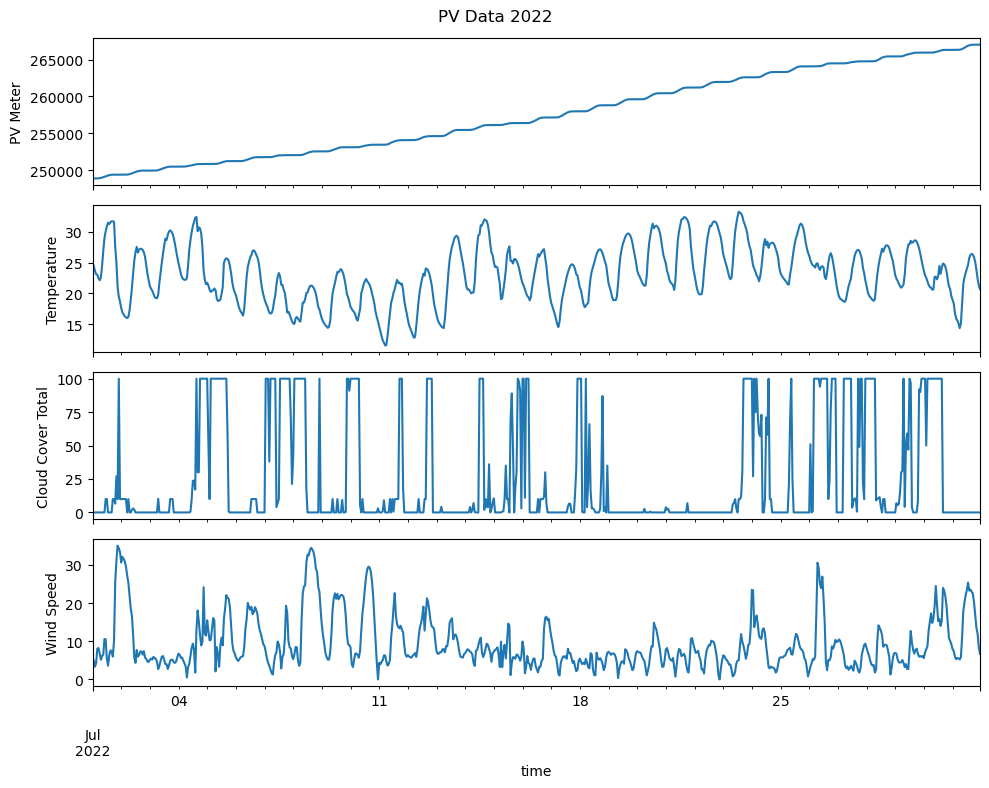

In [6]:
fig, axs = plt.subplots(4, 1, sharex=True, figsize=(10, 8))
for ax, col in zip(axs, df.columns[1:]):
    df.plot(x="time", y=col, ax=ax, ylabel=col, legend=False)
fig.suptitle("PV Data 2022")
fig.tight_layout()

## 3. PV Generation Statistics

Visualize the following:
- daily generation profile (scatter plot, including mean and standard deviation)
  - Hints: 
    1. create `PV generation` with `.diff()`
    2. use `.groupby('hour')`
    3. for the standard deviation `plt.fill_between()`is usefull
- create a boxplot analysis for all four data variables (`df.boxplot()`)  - Discuss and write down for what variables it is usefull and where some other operations (daily sum, daily average, ...) would make more sense and why

**Bonus:** Create additional statistics

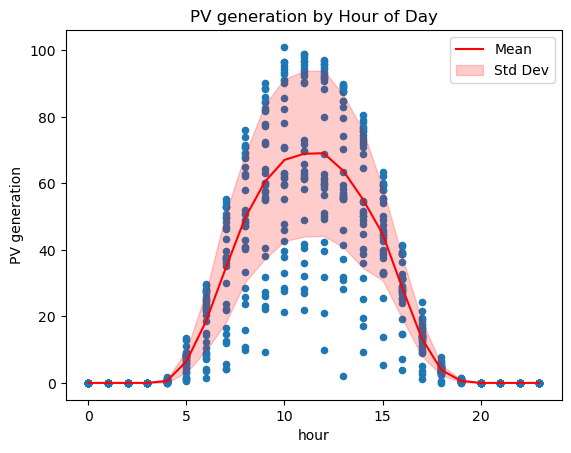

In [7]:
df["PV generation"] = df["PV Meter"].diff()

df["hour"] = df["time"].dt.hour
hourly_grouped = df.groupby("hour")

df.plot(
    x="hour",
    y="PV generation",
    kind="scatter",
    title="PV generation by Hour of Day",
    ylabel="PV generation",
    xlabel="Hour of Day",
)
hourly_grouped["PV generation"].mean().plot(label="Mean", color="red")
plt.fill_between(
    x=hourly_grouped["PV generation"].mean().index,
    y1=hourly_grouped["PV generation"].mean() - hourly_grouped["PV generation"].std(),
    y2=hourly_grouped["PV generation"].mean() + hourly_grouped["PV generation"].std(),
    alpha=0.2,
    color="red",
    label="Std Dev",
)
plt.legend()

<Axes: >

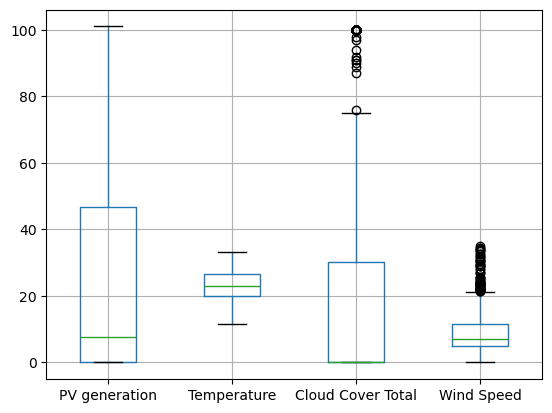

In [8]:
df.boxplot(["PV generation", "Temperature", "Cloud Cover Total", "Wind Speed"])

## 4. Correlation Analysis

Next the correlation between the PV generation and the cloud coverage should be investigated. (Hint: `df.plot.scatter()`)

In addition write down if the result is similar to your intuition and what is different (include potential couses).


<Axes: title={'center': 'Cloud Coverage vs PV Output (Daily Avg)'}, xlabel='Cloud Coverage', ylabel='PV Output'>

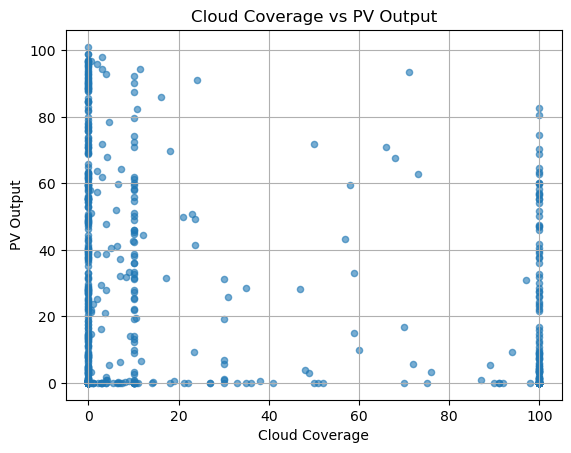

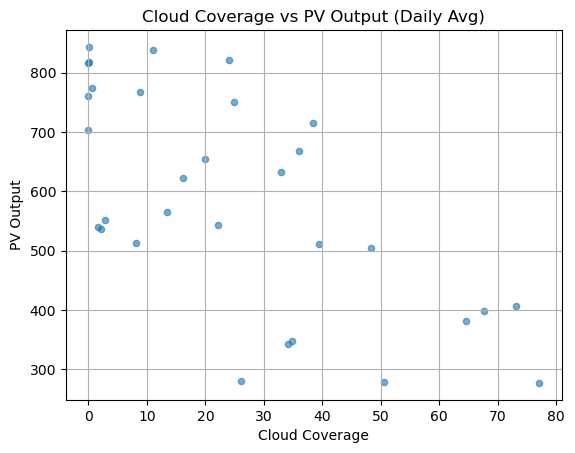

In [9]:
df.plot.scatter(
    x="Cloud Cover Total",
    y="PV generation",
    alpha=0.6,
    title="Cloud Coverage vs PV Output",
    xlabel="Cloud Coverage",
    ylabel="PV Output",
    grid=True,
)

df_daily = df.groupby(df["time"].dt.date).agg(
    {
        "PV generation": "sum",
        "Temperature": "mean",
        "Cloud Cover Total": "mean",
        "Wind Speed": "mean",
    }
)

df_daily.plot.scatter(
    x="Cloud Cover Total",
    y="PV generation",
    alpha=0.6,
    title="Cloud Coverage vs PV Output (Daily Avg)",
    xlabel="Cloud Coverage",
    ylabel="PV Output",
    grid=True,
)

In [10]:
# Compute correlation
corr = df[["Cloud Cover Total", "PV generation"]].corr()
corr_daily = df_daily[["Cloud Cover Total", "PV generation"]].corr()
print("\nCorrelation between Cloud Coverage and PV Output:")
print(corr, "\n")
print("Correlation between Cloud Coverage and PV Output (Daily Avg):")
print(corr_daily, "\n")


Correlation between Cloud Coverage and PV Output:
                   Cloud Cover Total  PV generation
Cloud Cover Total           1.000000      -0.157944
PV generation              -0.157944       1.000000 

Correlation between Cloud Coverage and PV Output (Daily Avg):
                   Cloud Cover Total  PV generation
Cloud Cover Total           1.000000      -0.669567
PV generation              -0.669567       1.000000 

